# SilverWalk 전처리 데이터 확인

`data/original_train_data/seoul_road_points.csv`를 전처리한 결과를 확인하는 노트북입니다.

확인 대상:

- `data/processed/original_train_train_preprocessed.csv`
- `data/processed/original_train_val_preprocessed.csv`
- `data/processed/original_train_test_preprocessed.csv`
- `artifacts/preprocessors/original_train_preprocess_config.json`
- `artifacts/preprocessors/original_train_preprocessor.joblib`

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT

PosixPath('/home/huichan/SPARV/SilverWalk')

## 1. 전처리 설정 확인

In [2]:
config_path = PROJECT_ROOT / "artifacts" / "preprocessors" / "original_train_preprocess_config.json"

with config_path.open("r", encoding="utf-8") as file:
    config = json.load(file)

summary = {
    "source_path": config["source_path"],
    "target_column": config["target_column"],
    "target_log_column": config["target_log_column"],
    "excluded_model_columns": config["excluded_model_columns"],
    "feature_count": len(config["feature_columns"]),
    "binary_count": len(config["binary_columns"]),
    "scaled_count": len(config["scale_columns"]),
    "log_scaled_count": len(config["log_scale_columns"]),
    "raw_scaled_count": len(config["raw_scale_columns"]),
    "split_sizes": config["split_sizes"],
}

summary

{'source_path': 'data/original_train_data/seoul_road_points.csv',
 'target_column': '위험도',
 'target_log_column': '위험도_log1p',
 'excluded_model_columns': ['POINT_ID', '위도', '경도', '위험도'],
 'feature_count': 102,
 'binary_count': 5,
 'scaled_count': 97,
 'log_scaled_count': 96,
 'raw_scaled_count': 1,
 'split_sizes': {'train': 315464, 'val': 67599, 'test': 67600}}

In [3]:
feature_checks = pd.DataFrame(
    [
        {"column": column, "in_feature_columns": column in config["feature_columns"]}
        for column in ["POINT_ID", "위도", "경도", "위험도", "위험도_log1p", "제한속도"]
    ]
)

feature_checks

,column,in_feature_columns
0,POINT_ID,False
1,위도,False
2,경도,False
3,위험도,False
4,위험도_log1p,False
5,제한속도,True


## 2. 전처리 데이터 로드

In [4]:
processed_dir = PROJECT_ROOT / "data" / "processed"

split_paths = {
    "train": processed_dir / "original_train_train_preprocessed.csv",
    "val": processed_dir / "original_train_val_preprocessed.csv",
    "test": processed_dir / "original_train_test_preprocessed.csv",
}

splits = {name: pd.read_csv(path) for name, path in split_paths.items()}

{name: frame.shape for name, frame in splits.items()}

{'train': (315464, 107), 'val': (67599, 107), 'test': (67600, 107)}

## 3. 기본 정보

In [5]:
basic_info = []

for name, frame in splits.items():
    basic_info.append(
        {
            "split": name,
            "rows": len(frame),
            "columns": len(frame.columns),
            "missing_cells": int(frame.isna().sum().sum()),
            "duplicate_POINT_ID": int(frame["POINT_ID"].duplicated().sum()),
            "risk_zero_count": int((frame["위험도"] == 0).sum()),
            "risk_positive_count": int((frame["위험도"] > 0).sum()),
            "risk_gt_50_count": int((frame["위험도"] > 50).sum()),
        }
    )

pd.DataFrame(basic_info)

,split,rows,columns,missing_cells,duplicate_POINT_ID,risk_zero_count,risk_positive_count,risk_gt_50_count
0,train,315464,107,0,0,252551,62913,491
1,val,67599,107,0,0,54118,13481,105
2,test,67600,107,0,0,54118,13482,105


In [6]:
splits["train"].head()

,POINT_ID,위도,경도,위험도,위험도_log1p,제한속도,고령인구수,사회복지시설개수,전통시장여부,버스정류장개수,버스승하차총승객수,지하철역개수,가로등개수,CCTV개수,보행자우선도로여부,공영주차장개수,노인장애인보호구역여부,과속방지턱개수,교차로개수,횡단보도예고표시여부,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식,과학·기술_광고,과학·기술_기술 서비스,과학·기술_기타 전문 과학,과학·기술_법무관련,과학·기술_본사·경영 컨설팅,과학·기술_사진 촬영,과학·기술_수의,과학·기술_시장 조사,과학·기술_인쇄·제품제작,과학·기술_전문 디자인,과학·기술_회계·세무,교육_교육 지원,교육_기타 교육,교육_일반 교육,보건의료_기타 보건,보건의료_병원,보건의료_의원,부동산_부동산 서비스,소매_가구 소매,소매_가전·통신 소매,소매_기타 상품 소매,소매_기타 생활용품 소매,소매_담배 소매,소매_모터사이클 소매,소매_섬유·의복·신발 소매,소매_시계·귀금속 소매,소매_식료품 소매,소매_식물 소매,소매_안경·정밀기기 소매,소매_애완동물·용품 소매,소매_연료 소매,소매_오락용품 소매,소매_음료 소매,소매_의약·화장품 소매,소매_자동차 부품 소매,소매_장식품 소매,소매_종합 소매,소매_중고 상품 소매,소매_철물·건설자재 소매,수리·개인_가전제품 수리,수리·개인_기타 가정용품 수리,수리·개인_기타 개인,수리·개인_모터사이클 수리,수리·개인_세탁,수리·개인_욕탕·신체관리,수리·개인_이용·미용,수리·개인_자동차 수리·세차,수리·개인_장례식장,수리·개인_컴퓨터 수리,수리·개인_통신장비 수리,숙박_기타 숙박,숙박_일반 숙박,시설관리·임대_가정용품 대여,시설관리·임대_고용 알선,시설관리·임대_기타 사업 서비스,시설관리·임대_사무 지원,시설관리·임대_산업용품 대여,시설관리·임대_시설관리,시설관리·임대_여행사·보조,시설관리·임대_운송장비 대여,시설관리·임대_조경·유지,시설관리·임대_청소·방제,예술·스포츠_도서관·사적지,예술·스포츠_스포츠 서비스,예술·스포츠_유원지·오락,음식_구내식당·뷔페,음식_기타 간이,음식_기타 외국,음식_동남아시아,음식_비알코올,음식_서양식,음식_일식,음식_주점,음식_중식,음식_한식,횡단보도개수,신호등설치여부
0,0,37.591080,126.992864,0.0,0.0,-1.948299,-0.083765,-0.467858,0,0.707413,-0.064923,-0.445421,-0.227168,-0.336967,0,-0.242595,0,-0.578324,-0.444967,0,-0.285796,-1.143294,-1.623695,-2.536654,-1.090277,-1.420068,-0.724560,-0.252952,-2.038178,-0.464226,0.146953,-1.376633,0.039419,-0.830084,-0.862574,0.434468,-0.820079,-0.449958,-1.111724,0.010039,-0.801667,-1.16499,-1.137771,-0.841374,-0.598624,-0.680716,-1.54431,-2.536654,-0.751011,-1.551545,-1.317189,-1.384319,-0.712456,-0.556744,-1.324632,-0.891696,-0.577158,-1.414033,-1.155418,-1.071046,-0.774735,-0.928714,-0.64701,-1.179351,-0.682565,1.135694,-0.859200,-0.877846,-1.466674,0.888586,-0.597294,-0.51022,-0.669982,-1.913152,-1.048801,-1.844865,-1.46704,-0.546987,-0.999802,-0.421781,-0.903801,-0.504384,-0.859668,0.216547,0.155934,0.620064,0.320457,-0.823161,-0.949905,0.93174,-0.312898,-0.821647,-1.013194,-1.763075,-1.467461,1.552034,-0.571171,-0.117071,0.223751,-0.262627,-0.574838,-0.215138,-1.604424,-0.665640,-0.540194,-0.717088,0
1,2,37.590820,126.992421,0.0,0.0,-1.948299,-0.083765,-0.467858,0,0.825222,-0.060792,-0.445421,-0.227168,-0.336967,0,-0.242595,0,-0.578324,-0.444967,0,-0.497542,-1.143294,-1.623695,-2.536654,-1.267055,-1.420068,-0.724560,-0.252952,-2.038178,-0.602714,-0.148271,-1.376633,0.039419,-0.830084,-0.862574,0.240953,-0.820079,-0.449958,-1.111724,-0.293604,-0.801667,-1.16499,-1.137771,-0.841374,-0.598624,-0.680716,-1.54431,-2.536654,-0.751011,-1.551545,-1.317189,-1.384319,-0.712456,-0.556744,-1.893778,-0.891696,-0.577158,-1.414033,-1.155418,-1.071046,-0.774735,-0.928714,-0.64701,-1.179351,-0.682565,0.859609,-1.075958,-0.877846,-1.466674,0.888586,-0.597294,-0.51022,-0.669982,-1.913152,-1.048801,-1.844865,-1.46704,-0.546987,-0.999802,-0.421781,-0.903801,-0.504384,-0.859668,0.216547,0.155934,0.620064,0.320457,-0.823161,-0.949905,0.93174,-0.312898,-0.821647,-1.013194,-1.763075,-1.467461,1.552034,-0.692211,-0.117071,0.223751,-0.506677,-0.574838,-0.215138,-1.604424,-1.432843,-0.668518,-0.717088,0
2,4,37.590492,126.992037,0.0,0.0,-1.948299,-0.083765,-0.467858,0,0.934296,0.200971,-0.445421,-0.227168,-0.336967,0,-0.242595,0,-0.578324,-0.444967,0,-0.547797,-1.785712,-1.623695,-2.536654,-1.267055,-1.777039,-0.724560,-0.364820,-2.038178,-0.628556,-0.148271,-1.376633,0.039419,-0.830084,-0.862574,0.004110,-0.820079,-0.449958,-1.111724,-0.293604,-0.801667,-1.16499,-1.837821,-1.237641,-0.598624,-0.680716,-1.54431,-2.536654,-0.751011,-1.551545,-1.317189,-1.384319,-0.712456,-0.556744,-1.893778,-0.891696,-0.577158,-1.414033,-1.155418,-1.071046,-0.774735,-0.928714,-0.64701,-1.179351,-0.682565,0.859609,-1.075958,-0.877846,-1.466674,0.888586,-1.523807,-0.51022,-0.669982,-1.913152,-1.048801,-2.440263,-1.46704,-0.546987,-0.999802,-0.421781,-0.903801,-0.504384,-0.859668,0.216547,0.155934,0.620064,-0.860414,-0.823161,-0.949905,0.93174,-0.312898,-0.821647,-1.013194,-1.763075,-1.467461,0.729686,-0.692211,-0.117071,0.22

## 4. 컬럼 구성 확인

In [7]:
column_roles = []

for column in splits["train"].columns:
    if column in config["id_columns"]:
        role = "지도/병합 키"
    elif column in config["coordinate_columns"]:
        role = "지도 표시용 좌표"
    elif column == config["target_column"]:
        role = "원본 타겟"
    elif column == config["target_log_column"]:
        role = "학습 타겟"
    elif column in config["binary_columns"]:
        role = "이진 피처"
    elif column in config["raw_scale_columns"]:
        role = "표준화 피처"
    elif column in config["log_scale_columns"]:
        role = "log1p 후 표준화 피처"
    else:
        role = "기타"

    column_roles.append(
        {
            "column": column,
            "role": role,
            "dtype": str(splits["train"][column].dtype),
        }
    )

column_roles_df = pd.DataFrame(column_roles)
column_roles_df

,column,role,dtype
0,POINT_ID,지도/병합 키,int64
1,위도,지도 표시용 좌표,float64
2,경도,지도 표시용 좌표,float64
3,위험도,원본 타겟,float64
4,위험도_log1p,학습 타겟,float64
5,제한속도,표준화 피처,float64
6,고령인구수,log1p 후 표준화 피처,float64
7,사회복지시설개수,log1p 후 표준화 피처,float64
8,전통시장여부,이진 피처,int64
9,버스정류장개수,log1p 후 표준화 피처,float64


In [8]:
column_roles_df["role"].value_counts().rename_axis("role").reset_index(name="count")

,role,count
0,log1p 후 표준화 피처,96
1,이진 피처,5
2,지도 표시용 좌표,2
3,원본 타겟,1
4,지도/병합 키,1
5,표준화 피처,1
6,학습 타겟,1


## 5. 타겟 분포 확인

In [9]:
target_summary = []

for name, frame in splits.items():
    risk = frame["위험도"]
    risk_log = frame["위험도_log1p"]
    target_summary.append(
        {
            "split": name,
            "risk_min": risk.min(),
            "risk_p50": risk.quantile(0.50),
            "risk_p75": risk.quantile(0.75),
            "risk_p90": risk.quantile(0.90),
            "risk_p95": risk.quantile(0.95),
            "risk_p99": risk.quantile(0.99),
            "risk_max": risk.max(),
            "risk_log_mean": risk_log.mean(),
            "risk_log_std": risk_log.std(),
        }
    )

pd.DataFrame(target_summary)

,split,risk_min,risk_p50,risk_p75,risk_p90,risk_p95,risk_p99,risk_max,risk_log_mean,risk_log_std
0,train,0.0,0.0,0.0,1.168,2.472,13.23636,317.160,0.176214,0.525420
1,val,0.0,0.0,0.0,1.168,2.472,12.70000,377.872,0.176820,0.525713
2,test,0.0,0.0,0.0,1.168,2.472,12.70000,221.376,0.175981,0.524233


array([[<Axes: title={'center': '위험도'}>,
        <Axes: title={'center': '위험도_log1p'}>]], dtype=object)

/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) 

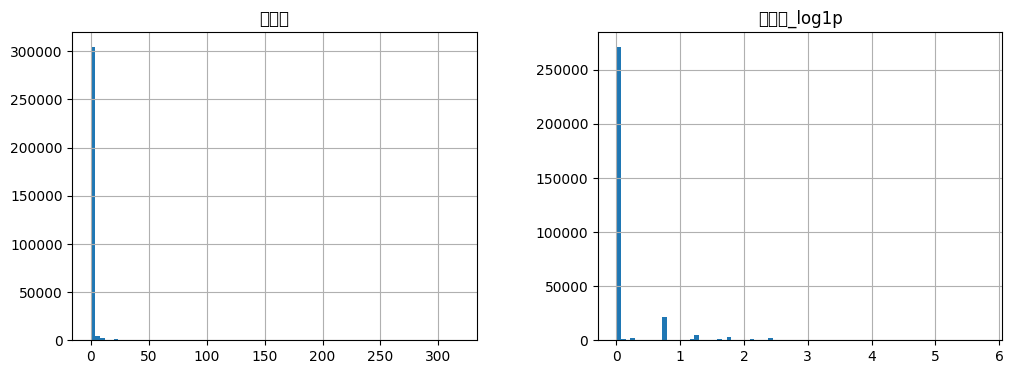

In [10]:
splits["train"][["위험도", "위험도_log1p"]].hist(bins=80, figsize=(12, 4))

## 6. 스케일링 결과 확인

In [11]:
scaled_columns = config["scale_columns"]
binary_columns = config["binary_columns"]

scaled_check = splits["train"][scaled_columns].agg(["mean", "std", "min", "max"]).T
scaled_check.head(30)

,mean,std,min,max
제한속도,-4.108329e-17,1.000002,-1.948299,4.170139
고령인구수,1.891273e-15,1.000002,-5.151681,1.057072
사회복지시설개수,1.491972e-16,1.000002,-0.467858,5.146664
버스정류장개수,-1.304575e-15,1.000002,-2.949938,1.954489
버스승하차총승객수,6.400344e-16,1.000002,-3.916230,1.113090
지하철역개수,-3.180351e-16,1.000002,-0.445421,4.273542
가로등개수,-1.183847e-16,1.000002,-0.227168,6.968806
CCTV개수,-1.326197e-16,1.000002,-0.336967,4.646153
공영주차장개수,1.463142e-16,1.000002,-0.242595,8.340547
과속방지턱개수,-4.000215e-17,1.000002,-0.578324,3.880690


In [12]:
binary_check = []

for column in binary_columns:
    values = sorted(splits["train"][column].dropna().unique().tolist())
    binary_check.append(
        {
            "column": column,
            "unique_values": values,
            "positive_ratio": splits["train"][column].mean(),
        }
    )

pd.DataFrame(binary_check)

,column,unique_values,positive_ratio
0,전통시장여부,"[0, 1]",0.092245
1,보행자우선도로여부,"[0, 1]",0.012908
2,노인장애인보호구역여부,"[0, 1]",0.139965
3,횡단보도예고표시여부,"[0, 1]",0.258942
4,신호등설치여부,"[0, 1]",0.194628


## 7. 저장된 전처리 객체 재사용 확인

In [13]:
from silverwalk_ai.features.preprocessing import OriginalTrainPreprocessor

preprocessor_path = PROJECT_ROOT / "artifacts" / "preprocessors" / "original_train_preprocessor.joblib"
preprocessor = OriginalTrainPreprocessor.load(preprocessor_path)

raw_sample = pd.read_csv(PROJECT_ROOT / config["source_path"], nrows=10)
transformed_sample = preprocessor.transform(raw_sample)

transformed_sample

,POINT_ID,위도,경도,위험도,위험도_log1p,제한속도,고령인구수,사회복지시설개수,전통시장여부,버스정류장개수,버스승하차총승객수,지하철역개수,가로등개수,CCTV개수,보행자우선도로여부,공영주차장개수,노인장애인보호구역여부,과속방지턱개수,교차로개수,횡단보도예고표시여부,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식,과학·기술_광고,과학·기술_기술 서비스,과학·기술_기타 전문 과학,과학·기술_법무관련,과학·기술_본사·경영 컨설팅,과학·기술_사진 촬영,과학·기술_수의,과학·기술_시장 조사,과학·기술_인쇄·제품제작,과학·기술_전문 디자인,과학·기술_회계·세무,교육_교육 지원,교육_기타 교육,교육_일반 교육,보건의료_기타 보건,보건의료_병원,보건의료_의원,부동산_부동산 서비스,소매_가구 소매,소매_가전·통신 소매,소매_기타 상품 소매,소매_기타 생활용품 소매,소매_담배 소매,소매_모터사이클 소매,소매_섬유·의복·신발 소매,소매_시계·귀금속 소매,소매_식료품 소매,소매_식물 소매,소매_안경·정밀기기 소매,소매_애완동물·용품 소매,소매_연료 소매,소매_오락용품 소매,소매_음료 소매,소매_의약·화장품 소매,소매_자동차 부품 소매,소매_장식품 소매,소매_종합 소매,소매_중고 상품 소매,소매_철물·건설자재 소매,수리·개인_가전제품 수리,수리·개인_기타 가정용품 수리,수리·개인_기타 개인,수리·개인_모터사이클 수리,수리·개인_세탁,수리·개인_욕탕·신체관리,수리·개인_이용·미용,수리·개인_자동차 수리·세차,수리·개인_장례식장,수리·개인_컴퓨터 수리,수리·개인_통신장비 수리,숙박_기타 숙박,숙박_일반 숙박,시설관리·임대_가정용품 대여,시설관리·임대_고용 알선,시설관리·임대_기타 사업 서비스,시설관리·임대_사무 지원,시설관리·임대_산업용품 대여,시설관리·임대_시설관리,시설관리·임대_여행사·보조,시설관리·임대_운송장비 대여,시설관리·임대_조경·유지,시설관리·임대_청소·방제,예술·스포츠_도서관·사적지,예술·스포츠_스포츠 서비스,예술·스포츠_유원지·오락,음식_구내식당·뷔페,음식_기타 간이,음식_기타 외국,음식_동남아시아,음식_비알코올,음식_서양식,음식_일식,음식_주점,음식_중식,음식_한식,횡단보도개수,신호등설치여부
0,0,37.591080,126.992864,0.0,0.0,-1.948299,-0.083765,-0.467858,0,0.707413,-0.064923,-0.445421,-0.227168,-0.336967,0,-0.242595,0,-0.578324,-0.444967,0,-0.285796,-1.143294,-1.623695,-2.536654,-1.090277,-1.420068,-0.724560,-0.252952,-2.038178,-0.464226,0.146953,-1.376633,0.039419,-0.830084,-0.862574,0.434468,-0.820079,-0.449958,-1.111724,0.010039,-0.801667,-1.16499,-1.137771,-0.841374,-0.598624,-0.680716,-1.54431,-2.536654,-0.751011,-1.551545,-1.317189,-1.384319,-0.712456,-0.556744,-1.324632,-0.891696,-0.577158,-1.414033,-1.155418,-1.071046,-0.774735,-0.928714,-0.64701,-1.179351,-0.682565,1.135694,-0.859200,-0.877846,-1.466674,0.888586,-0.597294,-0.51022,-0.669982,-1.913152,-1.048801,-1.844865,-1.46704,-0.546987,-0.999802,-0.421781,-0.903801,-0.504384,-0.859668,0.216547,0.155934,0.620064,0.320457,-0.823161,-0.949905,0.93174,-0.312898,-0.821647,-1.013194,-1.763075,-1.467461,1.552034,-0.571171,-0.117071,0.223751,-0.262627,-0.574838,-0.215138,-1.604424,-0.665640,-0.540194,-0.717088,0
1,1,37.590982,126.992616,0.0,0.0,-1.948299,-0.083765,-0.467858,0,0.707413,-0.064923,-0.445421,-0.227168,-0.336967,0,-0.242595,0,-0.578324,-0.444967,0,-0.323787,-1.143294,-1.623695,-2.536654,-1.145223,-1.420068,-0.724560,-0.252952,-2.038178,-0.577747,0.146953,-1.376633,0.039419,-0.830084,-0.862574,0.240953,-0.820079,-0.449958,-1.111724,0.010039,-0.801667,-1.16499,-1.137771,-0.841374,-0.598624,-0.680716,-1.54431,-2.536654,-0.751011,-1.551545,-1.317189,-1.384319,-0.712456,-0.556744,-1.324632,-0.891696,-0.577158,-1.414033,-1.155418,-1.071046,-0.774735,-0.928714,-0.64701,-1.179351,-0.682565,1.135694,-1.075958,-0.877846,-1.466674,0.888586,-0.597294,-0.51022,-0.669982,-1.913152,-1.048801,-1.844865,-1.46704,-0.546987,-0.999802,-0.421781,-0.903801,-0.504384,-0.859668,0.216547,0.155934,0.620064,0.320457,-0.823161,-0.949905,0.93174,-0.312898,-0.821647,-1.013194,-1.763075,-1.467461,1.552034,-0.692211,-0.117071,0.223751,-0.377005,-0.574838,-0.215138,-1.604424,-1.432843,-0.668518,-0.717088,0
2,2,37.590820,126.992421,0.0,0.0,-1.948299,-0.083765,-0.467858,0,0.825222,-0.060792,-0.445421,-0.227168,-0.336967,0,-0.242595,0,-0.578324,-0.444967,0,-0.497542,-1.143294,-1.623695,-2.536654,-1.267055,-1.420068,-0.724560,-0.252952,-2.038178,-0.602714,-0.148271,-1.376633,0.039419,-0.830084,-0.862574,0.240953,-0.820079,-0.449958,-1.111724,-0.293604,-0.801667,-1.16499,-1.137771,-0.841374,-0.598624,-0.680716,-1.54431,-2.536654,-0.751011,-1.551545,-1.317189,-1.384319,-0.712456,-0.556744,-1.893778,-0.891696,-0.577158,-1.414033,-1.155418,-1.071046,-0.774735,-0.928714,-0.64701,-1.179351,-0.682565,0.859609,-1.075958,-0.877846,-1.466674,0.888586,-0.597294,-0.51022,-0.669982,-1.913152,-1.048801,-1.844865,-1.46704,-0.546987,-0.999802,-0.421781,-0.903801,-0.504384,-0.859668,0.216547,0.155934,0.620064,0.320457,-0.823161,-0.949905,0.93174,-0.312898,-0.821647,-1.013194,-1.763075,-1.467461,1.552034,-0.692211,-0.117071,0.2237

In [14]:
{
    "loaded_preprocessor_fitted": preprocessor.fitted,
    "transformed_shape": transformed_sample.shape,
    "transformed_missing_cells": int(transformed_sample.isna().sum().sum()),
    "위도_in_model_features": "위도" in preprocessor.feature_columns,
    "경도_in_model_features": "경도" in preprocessor.feature_columns,
    "위험도_in_model_features": "위험도" in preprocessor.feature_columns,
}

{'loaded_preprocessor_fitted': True,
 'transformed_shape': (10, 107),
 'transformed_missing_cells': 0,
 '위도_in_model_features': False,
 '경도_in_model_features': False,
 '위험도_in_model_features': False}